In [3]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import plotly.express as px
import warnings
from sklearn.model_selection import train_test_split,RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier,GradientBoostingClassifier
from sklearn.metrics import accuracy_score,classification_report,ConfusionMatrixDisplay,precision_score,recall_score,f1_score,roc_auc_score,roc_curve
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

%matplotlib inline

In [4]:
# Read data from csv file
df = pd.read_csv('Travel.csv')

In [5]:
# Display first 5 records of data
df.head()

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


### Data Cleaning

In [6]:
# Check for missing values
df.isnull().sum()

CustomerID                    0
ProdTaken                     0
Age                         226
TypeofContact                25
CityTier                      0
DurationOfPitch             251
Occupation                    0
Gender                        0
NumberOfPersonVisiting        0
NumberOfFollowups            45
ProductPitched                0
PreferredPropertyStar        26
MaritalStatus                 0
NumberOfTrips               140
Passport                      0
PitchSatisfactionScore        0
OwnCar                        0
NumberOfChildrenVisiting     66
Designation                   0
MonthlyIncome               233
dtype: int64

In [7]:
# Check all categorical features
df['Gender'].value_counts()

Gender
Male       2916
Female     1817
Fe Male     155
Name: count, dtype: int64

In [8]:
df['Gender']=df['Gender'].replace('Fe Male','Female')
df['Gender'].value_counts()

Gender
Male      2916
Female    1972
Name: count, dtype: int64

In [9]:
df['MaritalStatus'].value_counts()

MaritalStatus
Married      2340
Divorced      950
Single        916
Unmarried     682
Name: count, dtype: int64

In [10]:
df['MaritalStatus']=df['MaritalStatus'].replace('Single','Unmarried')
df['MaritalStatus'].value_counts()

MaritalStatus
Married      2340
Unmarried    1598
Divorced      950
Name: count, dtype: int64

In [11]:
df['TypeofContact'].value_counts()

TypeofContact
Self Enquiry       3444
Company Invited    1419
Name: count, dtype: int64

In [12]:
# Handling missing values with NaN value
features_with_na=[features for features in df.columns if df[features].isnull().sum()>=1]
for feature in features_with_na:
    print(feature,np.round(df[feature].isnull().mean()*100,6),'% missing value')

Age 4.623568 % missing value
TypeofContact 0.511457 % missing value
DurationOfPitch 5.135025 % missing value
NumberOfFollowups 0.920622 % missing value
PreferredPropertyStar 0.531915 % missing value
NumberOfTrips 2.864157 % missing value
NumberOfChildrenVisiting 1.350245 % missing value
MonthlyIncome 4.766776 % missing value


In [13]:
# Statistics on numerical columns (null cols)
df[features_with_na].select_dtypes(exclude='object').describe()

,Age,DurationOfPitch,NumberOfFollowups,PreferredPropertyStar,NumberOfTrips,NumberOfChildrenVisiting,MonthlyIncome
count,4662.000000,4637.000000,4843.000000,4862.000000,4748.000000,4822.000000,4655.000000
mean,37.622265,15.490835,3.708445,3.581037,3.236521,1.187267,23619.853491
std,9.316387,8.519643,1.002509,0.798009,1.849019,0.857861,5380.698361
min,18.000000,5.000000,1.000000,3.000000,1.000000,0.000000,1000.000000
25%,31.000000,9.000000,3.000000,3.000000,2.000000,1.000000,20346.000000
50%,36.000000,13.000000,4.000000,3.000000,3.000000,1.000000,22347.000000
75%,44.000000,20.000000,4.000000,4.000000,4.000000,2.000000,25571.000000
max,61.000000,127.000000,6.000000,5.000000,22.000000,3.000000,98678.000000


In [14]:
### Imputing null values
# 1. Impute Median for Age column
# 2. Impute Mode for Type of contact column
# 3. Impute Median for Duration of pitch column
# 4. Impute Mode for Number of followups column as it is discrete feature
# 5. Impute Mode for Preferred property star column
# 6. Impute Median for Number of trips column
# 7. Impute Mode for Number of children visiting column
# 8. Impute Median for Monthly income column

In [15]:
# Age
df.Age.fillna(df.Age.median(),inplace=True)

#TypeofContact
df.TypeofContact.fillna(df.TypeofContact.mode()[0],inplace=True)

# DurationOfPitch
df.DurationOfPitch.fillna(df.DurationOfPitch.median(),inplace=True)

#NumberOfFollowups
df.NumberOfFollowups.fillna(df.NumberOfFollowups.mode()[0],inplace=True)

# PreferredPropertyStar
df.PreferredPropertyStar.fillna(df.PreferredPropertyStar.mode()[0],inplace=True)

#NumberOfTrips
df.NumberOfTrips.fillna(df.NumberOfTrips.median(),inplace=True)

#NumberOfChildrenVisiting
df.NumberOfChildrenVisiting.fillna(df.NumberOfChildrenVisiting.mode()[0],inplace=True)

#MonthlyIncome
df.MonthlyIncome.fillna(df.MonthlyIncome.median(),inplace=True)

In [16]:
df.isnull().sum()

CustomerID                  0
ProdTaken                   0
Age                         0
TypeofContact               0
CityTier                    0
DurationOfPitch             0
Occupation                  0
Gender                      0
NumberOfPersonVisiting      0
NumberOfFollowups           0
ProductPitched              0
PreferredPropertyStar       0
MaritalStatus               0
NumberOfTrips               0
Passport                    0
PitchSatisfactionScore      0
OwnCar                      0
NumberOfChildrenVisiting    0
Designation                 0
MonthlyIncome               0
dtype: int64

In [17]:
# Drop customer ID as we dont need it
df.drop('CustomerID',inplace=True,axis=1)

In [18]:
df.head()

,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Unmarried,1.0,1,2,1,0.0,Manager,20993.0
1,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Unmarried,7.0,1,3,0,0.0,Executive,17090.0
3,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,0,36.0,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


### Feature Engineering

In [19]:
# Create TotalVisiting feature 
df['TotalVisiting']=df['NumberOfPersonVisiting'] + df['NumberOfChildrenVisiting']
df.head()

,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome,TotalVisiting
0,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Unmarried,1.0,1,2,1,0.0,Manager,20993.0,3.0
1,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0,5.0
2,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Unmarried,7.0,1,3,0,0.0,Executive,17090.0,3.0
3,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0,3.0
4,0,36.0,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0,2.0


In [20]:
# Numerical Features
numerical_features=[feature for feature in df.columns if df[feature].dtype != 'O']
numerical_features
print('Number of numerical features : ',len(numerical_features))
print('List of numerical features :')
numerical_features

Number of numerical features :  14
List of numerical features :


['ProdTaken',
 'Age',
 'CityTier',
 'DurationOfPitch',
 'NumberOfPersonVisiting',
 'NumberOfFollowups',
 'PreferredPropertyStar',
 'NumberOfTrips',
 'Passport',
 'PitchSatisfactionScore',
 'OwnCar',
 'NumberOfChildrenVisiting',
 'MonthlyIncome',
 'TotalVisiting']

In [21]:
# Categorical Features
categorical_features=[feature for feature in df.columns if df[feature].dtype == 'O']
print('Number of categorical features : ',len(categorical_features))
print('List of categorical features :')
categorical_features

Number of categorical features :  6
List of categorical features :


['TypeofContact',
 'Occupation',
 'Gender',
 'ProductPitched',
 'MaritalStatus',
 'Designation']

In [22]:
# Discrete Features
discrete_features=[feature for feature in numerical_features if len(df[feature].unique()) <= 25]
print('Number of discrete features : ',len(discrete_features))
print('List of discrete features :')
discrete_features

Number of discrete features :  11
List of discrete features :


['ProdTaken',
 'CityTier',
 'NumberOfPersonVisiting',
 'NumberOfFollowups',
 'PreferredPropertyStar',
 'NumberOfTrips',
 'Passport',
 'PitchSatisfactionScore',
 'OwnCar',
 'NumberOfChildrenVisiting',
 'TotalVisiting']

In [23]:
# Continuous Features
continuous_features=[feature for feature in numerical_features if feature not in discrete_features]
print('Number of continuous features : ',len(continuous_features))
print('List of continuous features :')
continuous_features

Number of continuous features :  3
List of continuous features :


['Age', 'DurationOfPitch', 'MonthlyIncome']

In [24]:
df.head()

,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome,TotalVisiting
0,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Unmarried,1.0,1,2,1,0.0,Manager,20993.0,3.0
1,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0,5.0
2,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Unmarried,7.0,1,3,0,0.0,Executive,17090.0,3.0
3,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0,3.0
4,0,36.0,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0,2.0


### Train Test Split and model training

In [25]:
# Independent and dependent features
X = df.drop(['ProdTaken'],axis=1)
Y = df['ProdTaken']

In [26]:
X.head()

,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome,TotalVisiting
0,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Unmarried,1.0,1,2,1,0.0,Manager,20993.0,3.0
1,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0,5.0
2,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Unmarried,7.0,1,3,0,0.0,Executive,17090.0,3.0
3,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0,3.0
4,36.0,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0,2.0


In [27]:
Y.value_counts()

ProdTaken
0    3968
1     920
Name: count, dtype: int64

In [28]:
# Separate data for training and testing
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)
X_train.shape,X_test.shape

((3910, 19), (978, 19))

In [29]:
# Create column transformer
cat_features = X.select_dtypes(include="object").columns
num_features = X.select_dtypes(exclude="object").columns

stasca_transformer = StandardScaler()
oh_transformer = OneHotEncoder(drop='first')

preprocessor = ColumnTransformer([
    ('OneHotEncoder',oh_transformer,cat_features),
    ('StandardScaler',stasca_transformer,num_features)
])

In [30]:
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('OneHotEncoder', ...), ('StandardScaler', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``f

In [31]:
# Applying transformation in training dataset
X_train=preprocessor.fit_transform(X_train)

In [32]:
# Applying transformation in testing dataset
X_test=preprocessor.transform(X_test)

In [33]:
pd.DataFrame(X_train)

,0,1,2,3,4,5,6,7,8,9,...,18,19,20,21,22,23,24,25,26,27
0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,-1.252472,1.284279,-0.725271,-0.127737,-0.632399,0.679690,0.782966,-0.218050,-0.382245,-0.774151
1,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.129347,0.282777,-0.725271,1.511598,-0.632399,0.679690,0.782966,0.956297,-0.459799,0.643615
2,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.129347,0.282777,1.771041,0.418708,-0.632399,0.679690,0.782966,-0.218050,-0.245196,-0.065268
3,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,...,0.129347,1.284279,-0.725271,-0.127737,-0.632399,1.408395,-1.277194,-0.218050,0.213475,-0.065268
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.511165,-1.720227,-0.725271,1.511598,-0.632399,-0.049015,-1.277194,2.130645,-0.024889,2.061382
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3905,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.129347,1.284279,-0.725271,-0.674182,-0.632399,-1.506426,0.782966,0.956297,-0.536973,0.643615
3906,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.129347,-0.718725,1.771041,-1.220627,-0.632399,1.408395,0.782966,-0.218050,1.529609,-0.065268
3907,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.129347,0.282777,-0.725271,2.058043,-0.632399,-0.777720,0.782966,0.956297,-0.360576,0.643615
3908,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.129347,1.284279,-0.725271,-0.127737,-0.632399,-1.506426,0.782966,0.956297,-0.252799,0.643615


In [34]:
models = {
    "Logistic Regression" : LogisticRegression(),
    "Decision Tree" : DecisionTreeClassifier(),
    "Random Forest" : RandomForestClassifier(),
    "Gradient Boost" : GradientBoostingClassifier(),
    "Adaboost" : AdaBoostClassifier(),
    "XGBoost" : XGBClassifier()
}
for i in range(len(list(models))):
    model=list(models.values())[i]
    model.fit(X_train,Y_train)  #Train model

    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Training set performance
    model_train_accuracy = accuracy_score(Y_train,y_train_pred)
    model_train_f1=f1_score(Y_train,y_train_pred,average='weighted')
    model_train_precision=precision_score(Y_train,y_train_pred)
    model_train_recall=recall_score(Y_train,y_train_pred)
    model_train_rocauc_score=roc_auc_score(Y_train,y_train_pred)

    # Testing set performance
    model_test_accuracy = accuracy_score(Y_test,y_test_pred)
    model_test_f1=f1_score(Y_test,y_test_pred,average='weighted')
    model_test_precision=precision_score(Y_test,y_test_pred)
    model_test_recall=recall_score(Y_test,y_test_pred)
    model_test_rocauc_score=roc_auc_score(Y_test,y_test_pred)

    print(list(models.keys())[i])

    print('Model performance for training set')
    print('--- Accuracy : {:.4f}'.format(model_train_accuracy))
    print('--- F1 score : {:.4f}'.format(model_train_f1))
    print('--- Precision : {:.4f}'.format(model_train_precision))
    print('--- Recall : {:.4f}'.format(model_train_recall))
    print('--- ROC AUC score : {:.4f}'.format(model_train_rocauc_score))

    print('------------------------------------------------------------')

    print('Model performance for testing set')
    print('--- Accuracy : {:.4f}'.format(model_test_accuracy))
    print('--- F1 score : {:.4f}'.format(model_test_f1))
    print('--- Precision : {:.4f}'.format(model_test_precision))
    print('--- Recall : {:.4f}'.format(model_test_recall))
    print('--- ROC AUC score : {:.4f}'.format(model_test_rocauc_score))

    print('='*35)
    print('\n')

Logistic Regression
Model performance for training set
--- Accuracy : 0.8460
--- F1 score : 0.8206
--- Precision : 0.6991
--- Recall : 0.3059
--- ROC AUC score : 0.6379
------------------------------------------------------------
Model performance for testing set
--- Accuracy : 0.8354
--- F1 score : 0.8078
--- Precision : 0.6829
--- Recall : 0.2932
--- ROC AUC score : 0.6301


Decision Tree
Model performance for training set
--- Accuracy : 1.0000
--- F1 score : 1.0000
--- Precision : 1.0000
--- Recall : 1.0000
--- ROC AUC score : 1.0000
------------------------------------------------------------
Model performance for testing set
--- Accuracy : 0.9202
--- F1 score : 0.9193
--- Precision : 0.8156
--- Recall : 0.7644
--- ROC AUC score : 0.8612


Random Forest
Model performance for training set
--- Accuracy : 1.0000
--- F1 score : 1.0000
--- Precision : 1.0000
--- Recall : 1.0000
--- ROC AUC score : 1.0000
------------------------------------------------------------
Model performance for 

In [ ]:
# Hyperparameter tuning 
rf_params={
    'max_depth' : [5,8,15,None,10],
    'max_features' : [5,7,'auto',8],
    'min_samples_split' : [2,8,15,20],
    'n_estimators' : [100,200,500,1000]
}

xg_params = {
    'learning_rate' : [0.1,0.01],
    'max_depth' : [5,8,12,20,30],
    'n_estimators' : [100,200,300],
    'colsample_bytree' : [0.5,0.8,1,0.3,0.4]
}

In [38]:
xg_params

{'learning_rate': [0.1, 0.01],
 'max_depth': [5, 8, 12, 20, 30],
 'n_estimators': [100, 200, 300],
 'colsample_bytree': [0.5, 0.8, 1, 0.3, 0.4]}

In [39]:
# Models list for hyper parameter tuning 
randomcv_models=[
    ("RF",RandomForestClassifier(),rf_params),
    ("XG",XGBClassifier(),xg_params)
]

In [40]:
model_param = {}
for name, model, params in randomcv_models:
    random=RandomizedSearchCV(
        estimator=model,
        param_distributions=params,
        n_iter=100,
        verbose=2,
        cv=3,
        n_jobs=-1
    )
    random.fit(X_train,Y_train)
    model_param[name] = random.best_params_

for model_name in model_param:
    print(f'--------------best params for {model_name}------------------')
    print(model_param[model_name])


Fitting 3 folds for each of 100 candidates, totalling 300 fits
Fitting 3 folds for each of 100 candidates, totalling 300 fits
--------------best params for RF------------------
{'n_estimators': 500, 'min_samples_split': 2, 'max_features': 7, 'max_depth': None}
--------------best params for XG------------------
{'n_estimators': 300, 'max_depth': 20, 'learning_rate': 0.1, 'colsample_bytree': 0.8}


In [41]:
models = {
    "Random Forest" : RandomForestClassifier(
        n_estimators=500,
        min_samples_split=2,
        max_features=7,
        max_depth=None
    ),
    "XGBoost" : XGBClassifier(
        n_estimators=300,
        learning_rate=0.1,
        max_depth=20,
        colsample_bytree=0.8
    )
}
for i in range(len(list(models))):
    model=list(models.values())[i]
    model.fit(X_train,Y_train)  #Train model

    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Training set performance
    model_train_accuracy = accuracy_score(Y_train,y_train_pred)
    model_train_f1=f1_score(Y_train,y_train_pred,average='weighted')
    model_train_precision=precision_score(Y_train,y_train_pred)
    model_train_recall=recall_score(Y_train,y_train_pred)
    model_train_rocauc_score=roc_auc_score(Y_train,y_train_pred)

    # Testing set performance
    model_test_accuracy = accuracy_score(Y_test,y_test_pred)
    model_test_f1=f1_score(Y_test,y_test_pred,average='weighted')
    model_test_precision=precision_score(Y_test,y_test_pred)
    model_test_recall=recall_score(Y_test,y_test_pred)
    model_test_rocauc_score=roc_auc_score(Y_test,y_test_pred)

    print(list(models.keys())[i])

    print('Model performance for training set')
    print('--- Accuracy : {:.4f}'.format(model_train_accuracy))
    print('--- F1 score : {:.4f}'.format(model_train_f1))
    print('--- Precision : {:.4f}'.format(model_train_precision))
    print('--- Recall : {:.4f}'.format(model_train_recall))
    print('--- ROC AUC score : {:.4f}'.format(model_train_rocauc_score))

    print('------------------------------------------------------------')

    print('Model performance for testing set')
    print('--- Accuracy : {:.4f}'.format(model_test_accuracy))
    print('--- F1 score : {:.4f}'.format(model_test_f1))
    print('--- Precision : {:.4f}'.format(model_test_precision))
    print('--- Recall : {:.4f}'.format(model_test_recall))
    print('--- ROC AUC score : {:.4f}'.format(model_test_rocauc_score))

    print('='*35)
    print('\n')

Random Forest
Model performance for training set
--- Accuracy : 1.0000
--- F1 score : 1.0000
--- Precision : 1.0000
--- Recall : 1.0000
--- ROC AUC score : 1.0000
------------------------------------------------------------
Model performance for testing set
--- Accuracy : 0.9294
--- F1 score : 0.9245
--- Precision : 0.9552
--- Recall : 0.6702
--- ROC AUC score : 0.8313


XGBoost
Model performance for training set
--- Accuracy : 1.0000
--- F1 score : 1.0000
--- Precision : 1.0000
--- Recall : 1.0000
--- ROC AUC score : 1.0000
------------------------------------------------------------
Model performance for testing set
--- Accuracy : 0.9458
--- F1 score : 0.9434
--- Precision : 0.9539
--- Recall : 0.7592
--- ROC AUC score : 0.8751




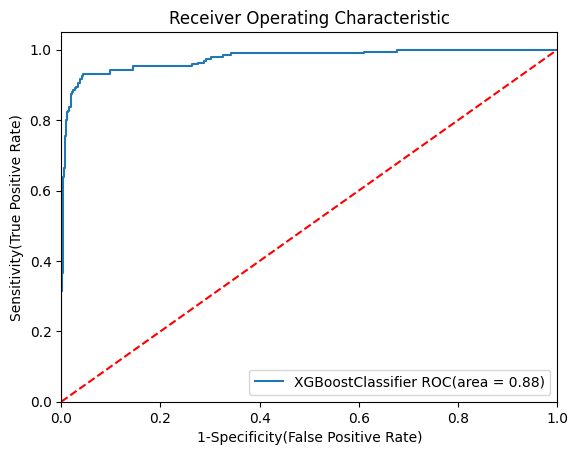

In [42]:
# Plot ROC AUC curve
plt.figure()

# Add models to the list that you want to view on ROC plot
auc_models=[{
    'label' : 'XGBoostClassifier',
    'model' : XGBClassifier(
        n_estimators=300,
        learning_rate=0.1,
        max_depth=20,
        colsample_bytree=0.8
    ),
    'auc' : 0.8751
}]

# create loop through all model
for algo in auc_models:
    model = algo['model'] # select the model
    model.fit(X_train, Y_train) # train the model
# Compute False postive rate, and True positive rate
    fpr, tpr, thresholds = roc_curve(Y_test, model.predict_proba(X_test)[:,1])
# Calculate Area under the curve to display on the plot
    plt.plot(fpr, tpr, label='%s ROC(area = %0.2f)' % (algo['label'], algo['auc']))
# Custom settings for the plot 
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('1-Specificity(False Positive Rate)')
plt.ylabel('Sensitivity(True Positive Rate)')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.savefig("auc.png")
plt.show()